<a href="https://colab.research.google.com/github/aljubic1/bioinformatika_projekt_alj/blob/main/notebooks/01_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. Data Preparation
U ovom notebooku prikazan je postupak pripreme podataka za klasifikaciju antimikrobnih peptida. Prikazani su koraci učitavanja podataka, provjere njihove kvalitete, čišćenja sekvenci, pripreme negativnog (non-AMP) skupa podataka te izrade konačnog uravnoteženog skupa koji će se koristiti u daljnjim fazama projekta.

## Cilj

Cilj ovog dijela projekta je učitati peptidne sekvence iz baze DBAASP, provjeriti njihovu kvalitetu te pripremiti skup podataka za daljnju bioinformatičku analizu. Tijekom pripreme podataka uklanjaju se neispravni zapisi, filtriraju monomerni peptidi, provjerava valjanost aminokiselinskih sekvenci te se formira očišćeni skup podataka koji će se koristiti u sljedećim fazama projekta.

1. Uvoz biblioteka

Učitavaju se potrebne biblioteke i pomoćne funkcije koje će se koristiti tijekom pripreme podataka, uključujući učitavanje, provjeru, čišćenje i spremanje skupa podataka.

In [ ]:
import sys

sys.path.append("/content/src")

from data_utils import (
    load_dataset,
    check_required_columns,
    print_dataset_info,
    check_missing_values,
    filter_monomers,
    clean_sequences,
    add_label,
    save_processed_dataset
)

2. Učitavanje skupa podataka

Učitava se izvorni skup podataka iz CSV datoteke te se prikazuje prvih nekoliko redaka radi provjere ispravnosti učitavanja.

In [ ]:
# Putanja do sirovih podataka.
raw_data_path = "/content/peptides.csv"

# Učitavanje podataka.
df = load_dataset(raw_data_path)

# Prikaz prvih pet redaka.
df.head()

,ID,COMPLEXITY,NAME,N TERMINUS,SEQUENCE,C TERMINUS,SYNTHESIS TYPE,TARGET GROUP,TARGET OBJECT
0,1,Multimer,Distinctin,NaN,NLVSGLIEARKYLEQLHRKLKNCKV ENREVPPGFTALIKTLR...,NaN,Ribosomal,Gram+ Gram-,Lipid Bilayer
1,3,Multimer,Halocidin,NaN,WLNALLHHGLNCAKGVLA ALLHHGLNCAKGVLA,AMD AMD,Ribosomal,Gram+,Lipid Bilayer
2,4,Multimer,Khal,NaN,KWLNALLHHGLNCAKGVLA ALLHHGLNCAKGVLA,AMD AMD,Synthetic,Gram+ Gram-,Lipid Bilayer
3,6,Multi-Peptide,Enterocin X,NaN,SNDSLWYGVGQFMGKQANCITNHPVKHMIIPGYCLSKILG IA...,NaN,Ribosomal,Gram+,Lipid Bilayer
4,7,Multi-Peptide,EAFP1 + EAFP2,NaN,XTCASRCPRPCNAGLCCSIYGYCGSGNAYCGAGNCRCQCRG X...,NaN,Ribosomal,Fungus,Lipid Bilayer


In [ ]:
# Zadržavanje samo monomernih peptida.
df_monomer = filter_monomers(df)

# Prikaz dimenzija nakon filtriranja.
print(df_monomer.shape)

# Prikaz prvih pet redaka.
df_monomer.head()

(1976, 9)


,ID,COMPLEXITY,NAME,N TERMINUS,SEQUENCE,C TERMINUS,SYNTHESIS TYPE,TARGET GROUP,TARGET OBJECT
0,8,Monomer,NaN,C16,KVvvKWVvKvVK,AMD,Synthetic,Gram+ Gram- Fungus,Lipid Bilayer
1,10,Monomer,NaN,NaN,LFIFFF,AMD,Synthetic,Gram+,Lipid Bilayer
2,11,Monomer,"Cathelicidin-1, CATH-1, Fowlicidin-1",NaN,RVKRVWPLVIRTVIAGYNLYRAIKKK,NaN,Ribosomal,Gram+ Gram- Cancer Mammalian Cell,Lipid Bilayer
3,12,Monomer,NaN,NaN,RKRIHIGPGRAFYTT,NaN,Synthetic,Gram+ Gram-,Lipid Bilayer
4,13,Monomer,RNal,ACT,RRXXRF,AMD,Synthetic,Gram+ Gram-,Lipid Bilayer


In [ ]:
# Čišćenje sekvenci.
df_clean = clean_sequences(df_monomer)

# Ispis dimenzija nakon čišćenja.
print(df_clean.shape)

# Prikaz prvih pet redaka.
df_clean.head()

(1672, 9)


,ID,COMPLEXITY,NAME,N TERMINUS,SEQUENCE,C TERMINUS,SYNTHESIS TYPE,TARGET GROUP,TARGET OBJECT
0,8,Monomer,NaN,C16,KVVVKWVVKVVK,AMD,Synthetic,Gram+ Gram- Fungus,Lipid Bilayer
1,10,Monomer,NaN,NaN,LFIFFF,AMD,Synthetic,Gram+,Lipid Bilayer
2,11,Monomer,"Cathelicidin-1, CATH-1, Fowlicidin-1",NaN,RVKRVWPLVIRTVIAGYNLYRAIKKK,NaN,Ribosomal,Gram+ Gram- Cancer Mammalian Cell,Lipid Bilayer
3,12,Monomer,NaN,NaN,RKRIHIGPGRAFYTT,NaN,Synthetic,Gram+ Gram-,Lipid Bilayer
4,14,Monomer,Brevinin-2 related peptide B2RP,NaN,GIWDTIKSMGKVFAGKILQNL,AMD,Ribosomal,Gram+ Gram- Virus Fungus Mammalian...,Lipid Bilayer Virus replication


In [ ]:
# Dodavanje oznake da se radi o antimikrobnim peptidima.
df_clean = add_label(df_clean, label=1)

# Prikaz prvih pet redaka.
df_clean.head()

,ID,COMPLEXITY,NAME,N TERMINUS,SEQUENCE,C TERMINUS,SYNTHESIS TYPE,TARGET GROUP,TARGET OBJECT,label
0,8,Monomer,NaN,C16,KVVVKWVVKVVK,AMD,Synthetic,Gram+ Gram- Fungus,Lipid Bilayer,1
1,10,Monomer,NaN,NaN,LFIFFF,AMD,Synthetic,Gram+,Lipid Bilayer,1
2,11,Monomer,"Cathelicidin-1, CATH-1, Fowlicidin-1",NaN,RVKRVWPLVIRTVIAGYNLYRAIKKK,NaN,Ribosomal,Gram+ Gram- Cancer Mammalian Cell,Lipid Bilayer,1
3,12,Monomer,NaN,NaN,RKRIHIGPGRAFYTT,NaN,Synthetic,Gram+ Gram-,Lipid Bilayer,1
4,14,Monomer,Brevinin-2 related peptide B2RP,NaN,GIWDTIKSMGKVFAGKILQNL,AMD,Ribosomal,Gram+ Gram- Virus Fungus Mammalian...,Lipid Bilayer Virus replication,1


In [ ]:
# Spremanje obrađenog skupa podataka.
save_processed_dataset(
    df_clean,
    "/content/amp_clean.csv"
)

In [ ]:
import os

os.listdir("/content")

['.config',
 'amp_clean.csv',
 'peptides.csv',
 'data_utils.py',
 '__pycache__',
 'sample_data']

In [ ]:
# Broj zapisa po tipu peptida.
df["COMPLEXITY"].value_counts()

,count
COMPLEXITY,
Monomer,1976
Multi-Peptide,21
Multimer,3


### Provjera nedostajućih vrijednosti

Prije daljnje obrade provjerene su nedostajuće vrijednosti u svim stupcima skupa podataka. Posebna pažnja posvećena je stupcu **SEQUENCE**, budući da predstavlja osnovu za izračun bioinformatičkih značajki. Rezultati pokazuju da stupac **SEQUENCE** ne sadrži nedostajuće vrijednosti, što omogućuje pouzdanu daljnju analizu. Nedostajuće vrijednosti u stupcima poput **NAME**, **N TERMINUS** i **C TERMINUS** nisu kritične jer se ti podaci ne koriste pri izračunu značajki niti tijekom treniranja modela.

In [ ]:
# Provjera nedostajućih vrijednosti.
check_missing_values(df)

,0
ID,0
COMPLEXITY,0
NAME,309
N TERMINUS,1857
SEQUENCE,0
C TERMINUS,1075
SYNTHESIS TYPE,0
TARGET GROUP,17
TARGET OBJECT,111


Tijekom pripreme podataka zadržani su samo monomerni peptidi. Nakon toga provedena je provjera valjanosti sekvenci kako bi se uklonili zapisi koji sadrže nestandardne aminokiseline ili druge nepravilnosti. U završnom koraku uklonjeni su duplikati, čime je dobiven pouzdan skup podataka za daljnju analizu.

### Izvještaj o čišćenju podataka

Nakon filtriranja monomernih peptida provedena je provjera valjanosti sekvenci. Uklonjene su sekvence koje sadrže nestandardne aminokiseline ili druge nepravilnosti te su uklonjeni duplikati. Na kraju je dobiven konačni skup podataka koji će se koristiti za ekstrakciju značajki i treniranje modela strojnog učenja.

In [ ]:
# Broj zapisa prije čišćenja.
before = len(df_monomer)

# Broj zapisa nakon čišćenja.
after = len(df_clean)

print("=" * 40)
print("IZVJEŠTAJ O ČIŠĆENJU PODATAKA")
print("=" * 40)
print(f"Monomeri prije čišćenja : {before}")
print(f"Monomeri nakon čišćenja : {after}")
print(f"Uklonjeno zapisa        : {before - after}")
print("=" * 40)

IZVJEŠTAJ O ČIŠĆENJU PODATAKA
Monomeri prije čišćenja : 1976
Monomeri nakon čišćenja : 1672
Uklonjeno zapisa        : 304


In [ ]:
# Dodavanje stupca s duljinom svake peptidne sekvence.
df_clean["sequence_length"] = df_clean["SEQUENCE"].apply(len)

# Prikaz osnovne statistike duljina sekvenci.
df_clean["sequence_length"].describe()

,sequence_length
count,1672.000000
mean,21.490431
std,12.771008
min,1.000000
25%,13.000000
50%,19.000000
75%,26.000000
max,119.000000


### Raspodjela duljina peptidnih sekvenci

Analiza duljine sekvenci važna je jer antimikrobni peptidi najčešće predstavljaju kraće lance aminokiselina. Duljina sekvence može utjecati na sposobnost peptida da se veže za membranu mikroorganizma i ostvari antimikrobno djelovanje.

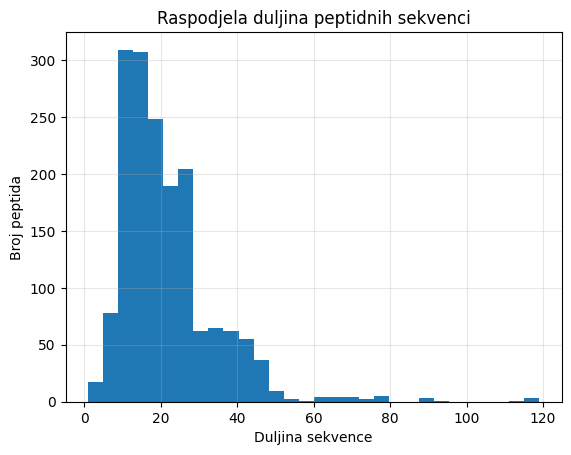

In [ ]:
# Uvoz biblioteke za izradu grafova.
import matplotlib.pyplot as plt

# Izrada histograma duljina peptidnih sekvenci.
plt.hist(df_clean["sequence_length"], bins=30)

# Dodavanje naslova grafa.
plt.title("Raspodjela duljina peptidnih sekvenci")

# Oznaka x-osi.
plt.xlabel("Duljina sekvence")

# Oznaka y-osi.
plt.ylabel("Broj peptida")

# Dodavanje mreže radi lakšeg očitavanja vrijednosti.
plt.grid(alpha=0.3)

### Interpretacija rezultata

Histogram pokazuje da većina antimikrobnih peptida u analiziranom skupu ima duljinu između približno 10 i 30 aminokiselina. Prosječna duljina iznosi oko 21 aminokiselinu, što je u skladu s poznatim svojstvima antimikrobnih peptida. Uočava se i manji broj duljih peptida koji predstavljaju rijetke primjere unutar baze DBAASP.

In [ ]:
#Broj zapisa kroz cjevovod
summary = {
    "Korak": [
        "Početni skup",
        "Monomeri",
        "Nakon čišćenja"
    ],
    "Broj zapisa": [
        len(df),
        len(df_monomer),
        len(df_clean)
    ]
}

import pandas as pd

pd.DataFrame(summary)

,Korak,Broj zapisa
0,Početni skup,2000
1,Monomeri,1976
2,Nakon čišćenja,1672


U ovom dijelu projekta uspješno je proveden postupak pripreme podataka. Iz baze DBAASP učitane su peptidne sekvence, izdvojeni su monomerni peptidi, uklonjene su neispravne i duplicirane sekvence te je formiran očišćeni skup podataka s 1672 antimikrobna peptida. Dobiveni skup podataka spremljen je u direktorij `data/processed/` i koristit će se u sljedećoj fazi projekta za izračun bioinformatičkih značajki.

# 7. Priprema negativnog (non-AMP) skupa podataka

Kako bi klasifikacijski model mogao razlikovati antimikrobne peptide od običnih peptida, potrebno je pripremiti i negativnu klasu (non-AMP).

Negativni skup preuzet je iz javno dostupnog AMPBenchmark skupa podataka. Iz FASTA datoteke izdvajaju se samo sekvence označene kao AMP=0, nakon čega prolaze istu provjeru kvalitete kao i pozitivni skup podataka.

In [ ]:
# Uvoz funkcija za rad s CSV datotekama.
from data_utils import (
    load_dataset,
    check_required_columns,
    print_dataset_info,
    check_missing_values,
    filter_monomers,
    clean_sequences,
    add_label,
    save_processed_dataset,
)

# Uvoz funkcija za rad s AMPBenchmark FASTA datotekama.
from data_utils import (
    load_ampbenchmark_fasta,
    extract_ampbenchmark_by_label,
)

Učitavanje FASTA datoteke

In [ ]:
# Putanja do AMPBenchmark FASTA datoteke.
fasta_path = "AMPBenchmark_public.fasta"

# Učitavanje FASTA datoteke.
ampbenchmark_df = load_ampbenchmark_fasta(fasta_path)

# Prikaz prvih nekoliko redaka.
ampbenchmark_df.head()

,ID,SEQUENCE
0,DBAASP_10018_AMP=1_rep1,WMLKKFRGMF
1,DBAASP_3217_AMP=1_rep1,AWRFKNIRK
2,DBAASP_11239_AMP=1_rep1,LIPFPFP
3,DBAASP_9251_AMP=1_rep1,PLLKKLLKKP
4,DBAASP_1175_AMP=1_rep1,QKKIRARLSA


In [ ]:
# Broj svih FASTA zapisa.
print(f"Ukupan broj FASTA zapisa: {len(ampbenchmark_df)}")

Ukupan broj FASTA zapisa: 128479


In [ ]:
# Izdvajanje negativnih (non-AMP) sekvenci.
non_amp_df = extract_ampbenchmark_by_label(
    ampbenchmark_df,
    label=0
)

# Prikaz prvih nekoliko redaka.
non_amp_df.head()

,ID,SEQUENCE,label
0,Seq2_sampling_method=iAMP-2L_AMP=0_rep1,MNVSNNAGIDSNDLAKRGESLIRKSTNRYLTTVRIAFRAKQRRFDD...,0
1,Seq3_sampling_method=iAMP-2L_AMP=0_rep1,MAKKSMIARDVKRKKIVERYAAKRAALMEAFNAAKDPMQRLEIHRK...,0
2,Seq22_sampling_method=iAMP-2L_AMP=0_rep1,KREHEKEVLQKAIEENNNFSKMAEEKLTTKMEAIKENREAQMAAKL...,0
3,Seq28_sampling_method=iAMP-2L_AMP=0_rep1,MVNAIKGVFVSCDIPMTQFIVNMNNSMPPSQKFIIHVLDSTHLFVQ...,0
4,Seq44_sampling_method=iAMP-2L_AMP=0_rep1,MYLFYVLLSSLFLSALIYVIGKSHPNLFMFISLFVNVVTILYLVFK...,0


In [ ]:
# Broj non-AMP sekvenci.
print(f"Broj non-AMP sekvenci: {len(non_amp_df)}")

Broj non-AMP sekvenci: 123284


Imamo:
•	AMP (DBAASP): 1 672 sekvence
•	non-AMP (AMPBenchmark): 123 284 sekvence
Nećemo koristiti svih 123 284 non-AMP sekvenci.
Zašto?
Ako model treniraš s:
•	1 672 AMP
•	123 284 non-AMP
on će naučiti predviđati gotovo sve kao non-AMP, jer je skup izrazito neuravnotežen.
Za projekt i za kvalitetu modela puno je bolje imati uravnotežen skup:
•	✅ 1 672 AMP
•	✅ 1 672 non-AMP
To je standardni pristup za ovakav tip projekta.


In [ ]:
# Nasumično odabiremo isti broj non-AMP sekvenci kao AMP sekvenci.
non_amp_sample = non_amp_df.sample(
    n=1672,
    random_state=42
)

# Resetiramo indeks.
non_amp_sample = non_amp_sample.reset_index(drop=True)

# Provjera dimenzija.
non_amp_sample.shape


(1672, 3)

In [ ]:
# Prikaz prvih nekoliko redaka.
non_amp_sample.head()


,ID,SEQUENCE,label
0,Seq1734_sampling_method=Wang-et-al_AMP=0_rep3,RELLERHYAQYDADDDETGE,0
1,Seq1021_sampling_method=AMAP_AMP=0_rep3,AQHNENNKETVMMPIIQLNADSYDFPHPKEALTEPNGL,0
2,Seq747_sampling_method=Witten&Witten_AMP=0_rep3,LRLREDENAEPVGTTYQK,0
3,Seq422_sampling_method=Wang-et-al_AMP=0_rep1,LEDQAPRRRPPIGYRPGGLQDSDTED,0
4,Seq1188_sampling_method=Gabere&Noble_AMP=0_rep4,QRAQSLLSTDRNASIDI,0


In [ ]:
# Spremanje negativnog skupa.
save_processed_dataset(
    non_amp_sample,
    "/content/non_amp_clean.csv"
)

In [ ]:
import pandas as pd


In [ ]:
amp_clean = pd.read_csv("/content/amp_clean.csv")

In [ ]:

# Učitavanje očišćenog AMP skupa.
amp_clean = pd.read_csv("/content/amp_clean.csv")

# Učitavanje očišćenog non-AMP skupa.
non_amp_clean = pd.read_csv("/content/non_amp_clean.csv")

# Zadržavamo samo stupce koji su potrebni za nastavak projekta.
amp_clean = amp_clean[["ID", "SEQUENCE", "label"]]
non_amp_clean = non_amp_clean[["ID", "SEQUENCE", "label"]]

# Spajamo pozitivnu i negativnu klasu u jedan skup podataka.
dataset = pd.concat([amp_clean, non_amp_clean], ignore_index=True)

# Miješamo redoslijed redaka radi neutralnosti pri kasnijem modeliranju.
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Provjera dimenzija konačnog skupa.
dataset.shape

(3344, 3)

In [ ]:
# Provjera raspodjele klasa.
dataset["label"].value_counts()

,count
label,
1,1672
0,1672


In [ ]:
save_processed_dataset(
    dataset,
    "/content/dataset.csv"
)

# Zaključak

U ovom dijelu projekta provedena je priprema podataka za klasifikaciju antimikrobnih peptida.

Pozitivni skup podataka preuzet je iz baze DBAASP, dok je negativni skup izdvojen iz javno dostupnog AMPBenchmark skupa podataka. Oba skupa prošla su postupak provjere i čišćenja sekvenci, pri čemu su uklonjene neispravne i duplicirane sekvence.

Kako bi se izbjegla neuravnoteženost klasa tijekom treniranja modela, iz negativnog skupa nasumično je odabrano 1672 sekvence, što odgovara broju pozitivnih primjera.

Na kraju je dobiven uravnotežen skup podataka koji sadrži ukupno **3344 peptidne sekvence** (1672 AMP i 1672 non-AMP). Ovaj skup predstavlja ulaz za sljedeću fazu projekta u kojoj će se izračunati bioinformatičke značajke potrebne za strojno učenje.

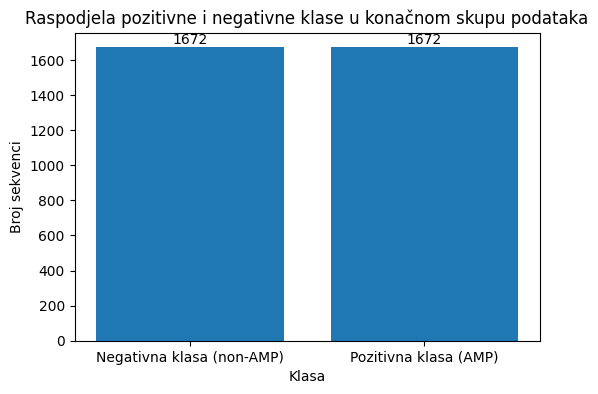

In [ ]:
# Uvoz biblioteke za crtanje grafova.
import matplotlib.pyplot as plt

# Izračun broja uzoraka u svakoj klasi.
class_counts = dataset["label"].value_counts().sort_index()

# Crtanje stupčastog grafa.
plt.figure(figsize=(6, 4))

plt.bar(
    ["Negativna klasa (non-AMP)", "Pozitivna klasa (AMP)"],
    class_counts.values
)


# Dodavanje naslova.
plt.title("Raspodjela pozitivne i negativne klase u konačnom skupu podataka")

# Naziv x osi.
plt.xlabel("Klasa")

# Naziv y osi.
plt.ylabel("Broj sekvenci")

# Dodavanje vrijednosti iznad stupaca.
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 20, str(value), ha="center")

# Prikaz grafa.
plt.show()

### Tumačenje rezultata

Na grafu je prikazana raspodjela klasa u konačnom skupu podataka korištenom za klasifikaciju peptida.

Može se uočiti da skup sadrži jednak broj antimikrobnih peptida (AMP) i neantimikrobnih peptida (non-AMP), odnosno po **1672 sekvence** u svakoj klasi.

Takva uravnotežena raspodjela važna je za strojno učenje jer sprječava pristranost modela prema brojnijoj klasi. Model će tijekom treniranja imati jednak broj pozitivnih i negativnih primjera, što omogućuje objektivniju procjenu njegove sposobnosti razlikovanja antimikrobnih i neantimikrobnih peptida.

In [ ]:
# Prikaz osnovnih informacija o konačnom skupu.
print("=" * 40)
print("FINAL DATASET")
print("=" * 40)

print(f"Ukupan broj sekvenci : {len(dataset)}")
print(f"AMP                 : {(dataset['label'] == 1).sum()}")
print(f"non-AMP             : {(dataset['label'] == 0).sum()}")

print("=" * 40)

FINAL DATASET
Ukupan broj sekvenci : 3344
AMP                 : 1672
non-AMP             : 1672
